# Rijstrookdetectie (Lane Detection) en grondprojectie

In dit notebook doorloop je alle stappen die nodig zijn voor lijndetectie en grondprojectie. De code voor lijndetectie is afkomstig uit de Paperspace-blogpost *“Understanding Hough Transform With A Lane Detection Model”*. Dit notebook is ontworpen om te worden uitgevoerd op Google Colab.

Bron: https://blog.paperspace.com/understanding-hough-transform-lane-detection/


## 1. Project setup

We installeren (indien nodig) de dependencies. Zorg ervoor dat de bestanden "test2.mp4" en "lane.jpg" aanwezig zijn in je werkmap.


## 2. Imports en hulpfuncties

We importeren OpenCV en NumPy en definiëren een helper om afbeeldingen netjes inline te tonen in Colab.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_rgb(img, title=None, figsize=(10,6)):
    """Toon een OpenCV BGR-afbeelding als RGB met matplotlib."""
    if img is None:
        raise ValueError("Afbeelding is None (bestand niet gevonden of niet leesbaar).")
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if len(img.shape)==3 else img
    plt.figure(figsize=figsize)
    if title:
        plt.title(title)
    plt.imshow(rgb, cmap='gray' if len(img.shape)==2 else None)
    plt.axis('off')
    plt.show()


## 3. Afbeelding laden en tonen

We beginnen met het inlezen van de afbeelding met `cv2.imread()`.  
In Colab tonen we de afbeelding inline.


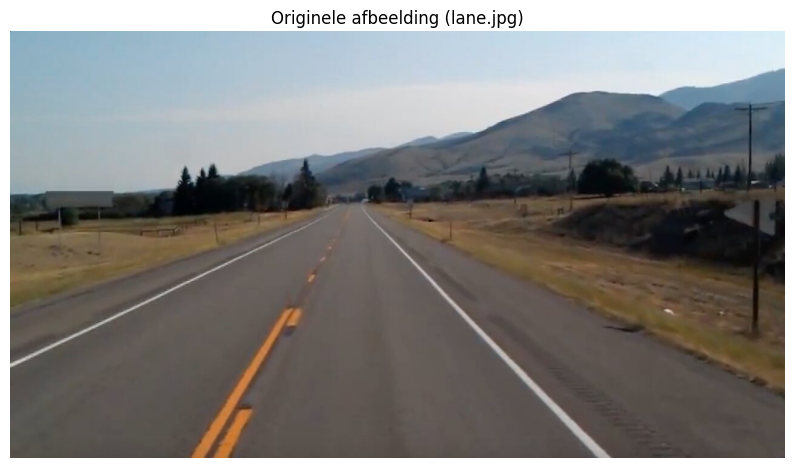

In [2]:
image = cv2.imread('lane.jpg')
lane_image = np.copy(image)

show_rgb(lane_image, title="Originele afbeelding (lane.jpg)")


## 4. Canny edge detection

Er zijn drie stappen in Canny edgedetectie:  
1. gray-scaling
2. ruisreductie met Gaussian blur
3. Canny edge detection.

We bundelen dit in één functie `canny()`.

Je kunt de hyperparameters in de onderstaande cel aanpassen om het effect op de edgedetectie te zien.


In [13]:
blur_kernel_size = 5 #  1, 3, 5, or 7
canny_low_threshold = 20
canny_high_threshold = 100

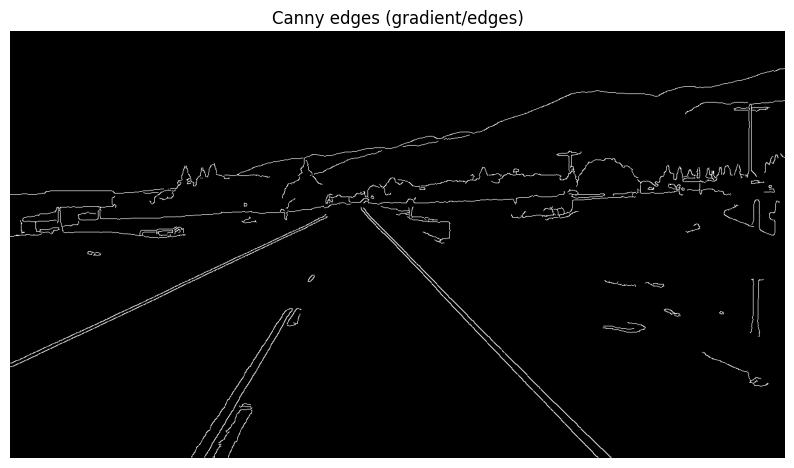

In [14]:
def canny(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (blur_kernel_size, blur_kernel_size), 0)
    canny_img = cv2.Canny(blur, canny_low_threshold, canny_high_threshold)
    return canny_img

canny_image = canny(lane_image)
show_rgb(canny_image, title="Canny edges (gradient/edges)")

## 5. Regio van interesse (ROI) isoleren

We maskeren alles behalve het driehoekige gebied waarin de rijstrooklijnen liggen, met `cv2.fillPoly()` en `cv2.bitwise_and()`. Gebruik onderstaande grafiek om te bepalen wat de hoekpunten van de driehoek moeten zijn. Pas ze indien nodig aan.


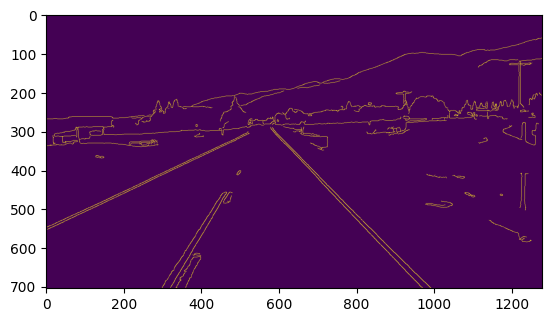

In [15]:
plt.imshow(canny_image)
plt.show()

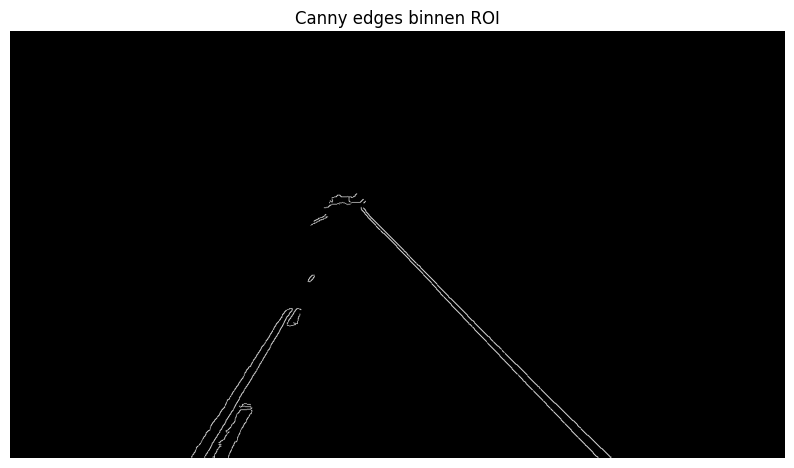

In [20]:
def region_of_interest(image):
    height = image.shape[0]
    width = image.shape[1]
    polygons = np.array([
        [(200, height), (1100, height), (550, 250)] # Adjust if necessary
    ])
    mask = np.zeros_like(image)
    cv2.fillPoly(mask, polygons, 255)
    masked_image = cv2.bitwise_and(image, mask)
    return masked_image

cropped_image = region_of_interest(canny_image)
show_rgb(cropped_image, title="Canny edges binnen ROI")


## 6. Hough Transform + hulpfuncties voor nette rijstrooklijnen

OpenCV biedt `cv2.HoughLinesP()` om lijnsegmenten te vinden.  
Daarna gebruiken we drie functies om segmenten te combineren tot twee “gemiddelde” rijstrooklijnen:

- `display_lines()` tekent lijnen op een zwart canvas en blendt dit met de originele afbeelding.
- `make_coordinates()` zet (slope, intercept) om naar (x1,y1,x2,y2).
- `average_slope_intercept()` splitst links/rechts en middelt de parameters.

Pas de hyperparameters in de onderstaande cel aan om het effect op de lijndetectie te zien.


In [21]:
rho = 2
theta = np.pi/180
threshold = 100
min_line_length = 40
max_line_gap = 5

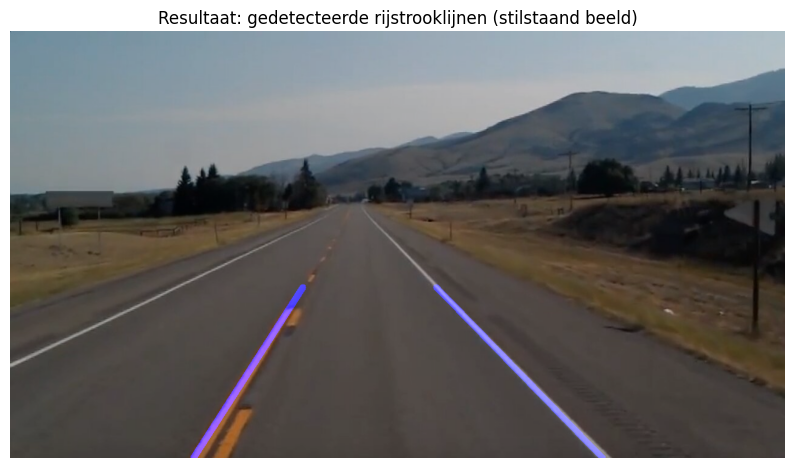

In [22]:
def display_lines(image, lines):
    line_image = np.zeros_like(image)
    if lines is not None:
        for x1, y1, x2, y2 in lines:
            cv2.line(line_image, (x1, y1), (x2, y2), (255, 0, 0), 10)
    return line_image

def make_coordinates(image, line_parameters):
    slope, intercept = line_parameters
    y1 = image.shape[0]
    y2 = int(y1 * (3/5))
    x1 = int((y1 - intercept) / slope)
    x2 = int((y2 - intercept) / slope)
    return np.array([x1, y1, x2, y2])

def average_slope_intercept(image, lines):
    left_fit = []
    right_fit = []
    for line in lines:
        x1, y1, x2, y2 = line.reshape(4)
        parameters = np.polyfit((x1, x2), (y1, y2), 1)
        slope = parameters[0]
        intercept = parameters[1]
        if slope < 0:
            left_fit.append((slope, intercept))
        else:
            right_fit.append((slope, intercept))
    left_fit_average = np.average(left_fit, axis=0)
    right_fit_average = np.average(right_fit, axis=0)
    left_line = make_coordinates(image, left_fit_average)
    right_line = make_coordinates(image, right_fit_average)
    return np.array([left_line, right_line])

lines = cv2.HoughLinesP(
    cropped_image,
    rho,
    theta,
    threshold,
    np.array([]),
    minLineLength=min_line_length,
    maxLineGap=max_line_gap
)

averaged_lines = average_slope_intercept(lane_image, lines)
line_image = display_lines(lane_image, averaged_lines)
combo_image = cv2.addWeighted(lane_image, 0.8, line_image, 1, 1)

show_rgb(combo_image, title="Resultaat: gedetecteerde rijstrooklijnen (stilstaand beeld)")


## 7. Rijstrookdetectie op video

We lezen een video frame-voor-frame in met `cv2.VideoCapture` en tonen het live met `cv2.imshow()`.  
In Colab schrijven we een **outputvideo** weg met `cv2.VideoWriter` en tonen we daarna het resultaat inline.


In [23]:
def average_slope_intercept(image, lines):
    left_fit = []
    right_fit = []
    if lines is None: # Handle case where HoughLinesP returns no lines at all
        return None

    for line in lines:
        x1, y1, x2, y2 = line.reshape(4)
        # Handle nearly vertical lines to prevent extremely large slopes
        # which can cause issues with line calculations. This also avoids division by zero.
        if abs(x2 - x1) < 1:
            continue

        parameters = np.polyfit((x1, x2), (y1, y2), 1)
        slope = parameters[0]
        intercept = parameters[1]

        if slope < 0: # Left lane lines typically have negative slope
            left_fit.append((slope, intercept))
        else: # Right lane lines typically have positive slope
            right_fit.append((slope, intercept))

    averaged_lines = []
    if len(left_fit) > 0:
        left_fit_average = np.average(left_fit, axis=0)
        left_line = make_coordinates(image, left_fit_average)
        averaged_lines.append(left_line)

    if len(right_fit) > 0:
        right_fit_average = np.average(right_fit, axis=0)
        right_line = make_coordinates(image, right_fit_average)
        averaged_lines.append(right_line)

    if not averaged_lines:
        return None # Return None if no averaged lines were found to be drawn

    return np.array(averaged_lines)

from pathlib import Path

input_path = "test2.mp4"
output_path = "test2_lanes_out.mp4"

cap = cv2.VideoCapture(input_path)
if not cap.isOpened():
    raise RuntimeError(f"Kan video niet openen: {input_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Gebruik mp4v codec (werkt meestal in Colab)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps if fps > 0 else 20.0, (width, height))

frame_count = 0
max_frames = None  # zet bv. op 300 voor sneller testen

while True:
    ret, frame = cap.read()
    if not ret:
        break

    canny_img = canny(frame)
    cropped = region_of_interest(canny_img)
    lines = cv2.HoughLinesP(cropped, 2, np.pi/180, 100, np.array([]), minLineLength=40, maxLineGap=5)

    # Use the modified average_slope_intercept function
    averaged_lines_result = average_slope_intercept(frame, lines)

    if averaged_lines_result is not None:
        line_img = display_lines(frame, averaged_lines_result)
        combo = cv2.addWeighted(frame, 0.8, line_img, 1, 1)
    else:
        combo = frame # If no lines detected, just use the original frame

    out.write(combo)

    frame_count += 1
    if max_frames is not None and frame_count >= max_frames:
        break

cap.release()
out.release()

print(f"Klaar. Verwerkte frames: {frame_count}")
print("Outputvideo:", output_path)

Klaar. Verwerkte frames: 1295
Outputvideo: test2_lanes_out.mp4


Je hebt nu dezelfde pipeline als in de blogpost:

**inlezen → Canny → ROI → HoughLinesP → middelen van lijnen → overlay**, toegepast op zowel een afbeelding als een video.


## 8 Grondprojectie hulpfuncties

De rest van het notebook laat zien hoe je:
1. Een homografie kalibreert met **checkerboard-hoekdetectie** op basis van een **checkerboard** (referentiebeeld ↔ camerabeeld).
2. Die homografie toepast om **gedetecteerde rijstrooklijnen** (bijv. uit Hough) te projecteren naar het **grondvlak** (bird's-eye/2D).
3. De geprojecteerde lijnen visualiseert op een **2D-grid**.

> **Benodigd:**
> - `checkerboard_ref.png` : referentie/top-down afbeelding van het checkerboard (template).
> - `checkerboard_cam.jpg` : camerabeeld van hetzelfde checkerboard.
> - (optioneel) `lane.jpg` : een wegbeeld waarop je rijstrooklijnen detecteert.

Als je al rijstrooklijnen detecteert (bijv. via Canny + Hough), dan kun je de resulterende lijnsegmenten direct doorgeven aan de projectiestap.

**Hulpfuncties**

We definiëren:
- Checkerboard-hoekdetectie
- Homografie-schatting met RANSAC
- Punt- en lijnprojectie met homografie
- Visualisatiehelpers


In [24]:
def lees_bgr(path: str):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Kon bestand niet lezen: {path}")
    return img

def vind_checkerboard_hoeken(img_bgr, pattern_size=(7,5), use_sb=True):
    """Vind INNER corners van een checkerboard.

    pattern_size = (aantal inner corners per rij, aantal inner corners per kolom)

    Let op: dit is niet het aantal vakjes, maar het aantal *kruispunten binnenin*.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Preprocessing helpt vaak bij lage resolutie/ruis
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    if use_sb and hasattr(cv2, "findChessboardCornersSB"):
        flags = cv2.CALIB_CB_NORMALIZE_IMAGE
        ret, corners = cv2.findChessboardCornersSB(gray, pattern_size, flags=flags)
    else:
        flags = cv2.CALIB_CB_ADAPTIVE_THRESH | cv2.CALIB_CB_NORMALIZE_IMAGE
        ret, corners = cv2.findChessboardCorners(gray, pattern_size, flags=flags)
        if ret:
            # Sub-pixel verfijning
            term = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 50, 1e-4)
            corners = cv2.cornerSubPix(gray, corners, (11,11), (-1,-1), term)

    if not ret:
        raise RuntimeError(
            "Checkerboard corners niet gevonden. Controleer pattern_size (inner corners) en beeldkwaliteit."
        )
    return corners  # shape: (N,1,2)

def schat_homografie_checkerboard(cam_bgr, ref_bgr, pattern_size=(7,5), ransac_thresh=2.0):
    """Schat homografie H: camera -> referentie/grondvlak (op basis van checkerboard-hoeken)."""
    cam_corners = vind_checkerboard_hoeken(cam_bgr, pattern_size=pattern_size, use_sb=True)
    ref_corners = vind_checkerboard_hoeken(ref_bgr, pattern_size=pattern_size, use_sb=True)

    H, inlier_mask = cv2.findHomography(cam_corners, ref_corners, cv2.RANSAC, ransac_thresh)
    if H is None:
        raise RuntimeError("Homografie kon niet geschat worden.")
    return H, cam_corners, ref_corners, inlier_mask

def teken_corners(img_bgr, corners, pattern_size, titel):
    vis = img_bgr.copy()
    cv2.drawChessboardCorners(vis, pattern_size, corners, True)
    plt.figure(figsize=(10, 4))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(titel)
    plt.axis("off")
    plt.show()

def transformeer_punten(H, punten_xy):
    """Transformeer Nx2 punten met homografie H."""
    pts = np.asarray(punten_xy, dtype=np.float32).reshape(-1, 1, 2)
    pts_t = cv2.perspectiveTransform(pts, H).reshape(-1, 2)
    return pts_t

def projecteer_lijnen(H, lijnen_xyxy):
    """Projecteer lijnsegmenten (x1,y1,x2,y2) naar referentie/grondvlak."""
    lijnen_xyxy = np.asarray(lijnen_xyxy, dtype=np.float32)
    if lijnen_xyxy.ndim != 2 or lijnen_xyxy.shape[1] != 4:
        raise ValueError("lijnen_xyxy moet vorm (N,4) hebben met (x1,y1,x2,y2).")

    p1 = lijnen_xyxy[:, 0:2]
    p2 = lijnen_xyxy[:, 2:4]
    p1_t = transformeer_punten(H, p1)
    p2_t = transformeer_punten(H, p2)
    return np.hstack([p1_t, p2_t])  # (N,4)

def plot_grond_lijnen(lijnen_grond_xyxy, titel="Grond-geprojecteerde lijnen", equal_aspect=True):
    lijnen = np.asarray(lijnen_grond_xyxy, dtype=np.float32)
    if len(lijnen) == 0:
        raise ValueError("Geen lijnen om te plotten.")

    xs = np.hstack([lijnen[:, 0], lijnen[:, 2]])
    ys = np.hstack([lijnen[:, 1], lijnen[:, 3]])

    # Marges
    margin = 0.05
    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()
    dx = (x_max - x_min) if (x_max > x_min) else 1.0
    dy = (y_max - y_min) if (y_max > y_min) else 1.0

    x_min -= margin * dx
    x_max += margin * dx
    y_min -= margin * dy
    y_max += margin * dy

    plt.figure(figsize=(8, 8))
    ax = plt.gca()

    for (x1, y1, x2, y2) in lijnen:
        ax.plot([x1, x2], [y1, y2])

    ax.set_title(titel)
    ax.set_xlabel("X (grondvlak / referentie)")
    ax.set_ylabel("Y (grondvlak / referentie)")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    if equal_aspect:
        ax.set_aspect("equal", adjustable="box")

    # Gridlines aan
    ax.grid(True)

    plt.show()


## 9. Beelden laden
Pas de paden aan als je andere bestandsnamen gebruikt.

Checkerboard cam shape: (747, 1600, 3)
Checkerboard ref shape: (514, 688, 3)


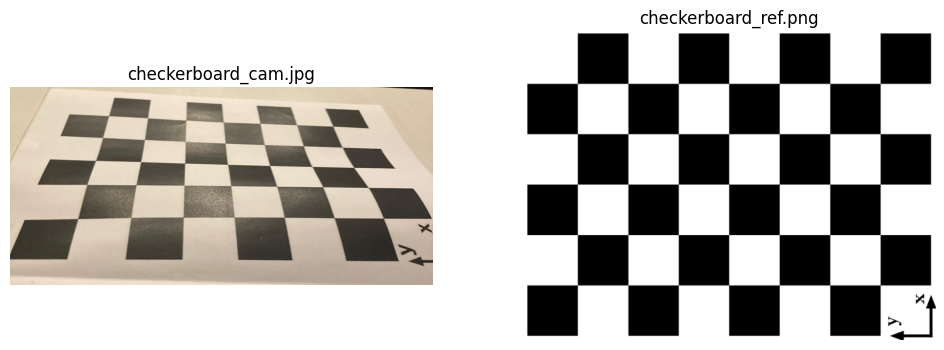

In [25]:
pad_cam = "checkerboard_cam.jpg"
pad_ref = "checkerboard_ref.png"

checkerboard_cam = lees_bgr(pad_cam)
checkerboard_ref = lees_bgr(pad_ref)

print("Checkerboard cam shape:", checkerboard_cam.shape)
print("Checkerboard ref shape:", checkerboard_ref.shape)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(checkerboard_cam, cv2.COLOR_BGR2RGB))
plt.title("checkerboard_cam.jpg")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(checkerboard_ref, cv2.COLOR_BGR2RGB))
plt.title("checkerboard_ref.png")
plt.axis("off")
plt.show()


## 10. Checkerboard patroon instellen (inner corners)
OpenCV verwacht **inner corners**:
- Als je checkerboard bijvoorbeeld 8×6 vakjes heeft, dan zijn er **7×5 inner corners**.

Als je niet zeker bent, probeer dan `(7,5)` en `(5,7)`.


In [28]:
# Probeer eerst (8,5). Werkt dat niet, probeer (7,5) of (5,7).
pattern_size = (7, 5)

## 11. Homografie schatten (camera → referentie/grondvlak)
We detecteren hoeken in beide beelden en schatten daarna de homografie met RANSAC.


In [29]:
try:
    H_img2ref, cam_corners, ref_corners, inlier_mask = schat_homografie_checkerboard(
        checkerboard_cam, checkerboard_ref, pattern_size=pattern_size, ransac_thresh=2.0
    )
except RuntimeError as e:
    print("Mislukt met pattern_size =", pattern_size, "\n", e)
    print("Probeer nu pattern_size = (5,7)")
    pattern_size = (5, 7)
    H_img2ref, cam_corners, ref_corners, inlier_mask = schat_homografie_checkerboard(
        checkerboard_cam, checkerboard_ref, pattern_size=pattern_size, ransac_thresh=2.0
    )

print("Gebruikte pattern_size (inner corners):", pattern_size)
print("Homografie H_img2ref (camera → referentie):\n", H_img2ref)

Gebruikte pattern_size (inner corners): (7, 5)
Homografie H_img2ref (camera → referentie):
 [[ 5.98256154e-01  2.76068367e-01 -1.57803423e+02]
 [-5.66744029e-02  1.36838658e+00 -4.54102993e+01]
 [-9.62264067e-05  9.98582938e-04  1.00000000e+00]]


## 12. Visualisatie: gevonden hoeken
We tekenen de gedetecteerde corners in beide beelden om te verifiëren dat het patroon correct is.


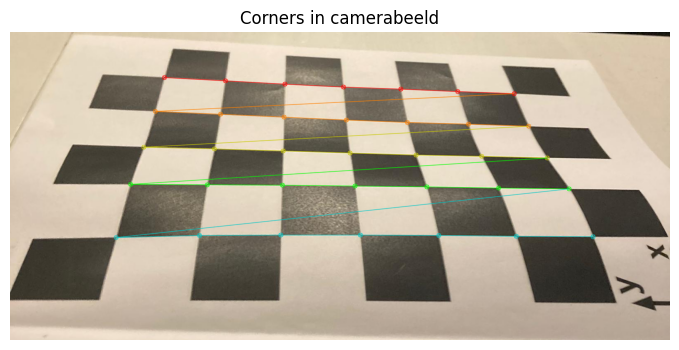

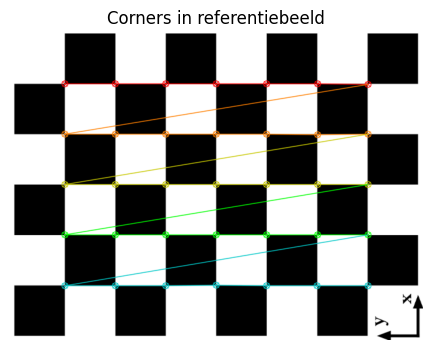

In [30]:
teken_corners(checkerboard_cam, cam_corners, pattern_size, "Corners in camerabeeld")
teken_corners(checkerboard_ref, ref_corners, pattern_size, "Corners in referentiebeeld")


## 13. Sanity check: projecteer camerahoeken naar referentie
We projecteren de vier hoeken van het camerabeeld naar referentiecoördinaten.
Als de homografie klopt, liggen deze punten logisch t.o.v. het referentiebeeld.


Camerahoeken → referentiepunten:
 [[-157.80342   -45.4103  ]
 [ 944.0682   -160.76965 ]
 [ 631.4938    556.0911  ]
 [  27.590347  558.9903  ]]


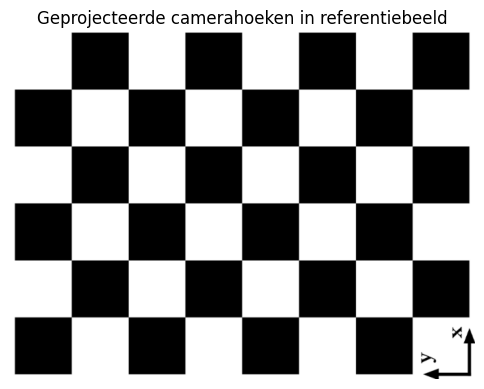

In [31]:
h, w = checkerboard_cam.shape[:2]
hoeken_cam = np.array([[0, 0], [w-1, 0], [w-1, h-1], [0, h-1]], dtype=np.float32)
hoeken_ref = transformeer_punten(H_img2ref, hoeken_cam)

print("Camerahoeken → referentiepunten:\n", hoeken_ref)

ref_vis = checkerboard_ref.copy()
for (x, y) in hoeken_ref.astype(int):
    cv2.circle(ref_vis, (int(x), int(y)), 8, (0, 0, 255), -1)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(ref_vis, cv2.COLOR_BGR2RGB))
plt.title("Geprojecteerde camerahoeken in referentiebeeld")
plt.axis("off")
plt.show()


## 14. Lijnen projecteren naar het grondvlak met de homografie
We nemen de lijnsegmenten `(x1,y1,x2,y2)` uit het camerabeeld (bijv. uit Hough) en projecteren de eindpunten met `H_img2ref`.

De uitkomst zijn lijnsegmenten in referentie/grondvlak-coördinaten.


In [32]:
lijnen_cam = lines.reshape(-1, 4).astype(np.float32)

lijnen_grond = projecteer_lijnen(H_img2ref, lijnen_cam)
print("Aantal lijnsegmenten (camera):", len(lijnen_cam))
print("Aantal lijnsegmenten (grondvlak):", len(lijnen_grond))


Aantal lijnsegmenten (camera): 20
Aantal lijnsegmenten (grondvlak): 20


## 15. Plot: grond-geprojecteerde lijnen op 2D-grid (met gridlines)
We plotten de geprojecteerde lijnen in een 2D-plot met zichtbare gridlines.

> Let op: de eenheden zijn in dit geval **pixels van het referentiebeeld**.
> Wil je meters, schaal dan met de bekende vakjesgrootte van het checkerboard.


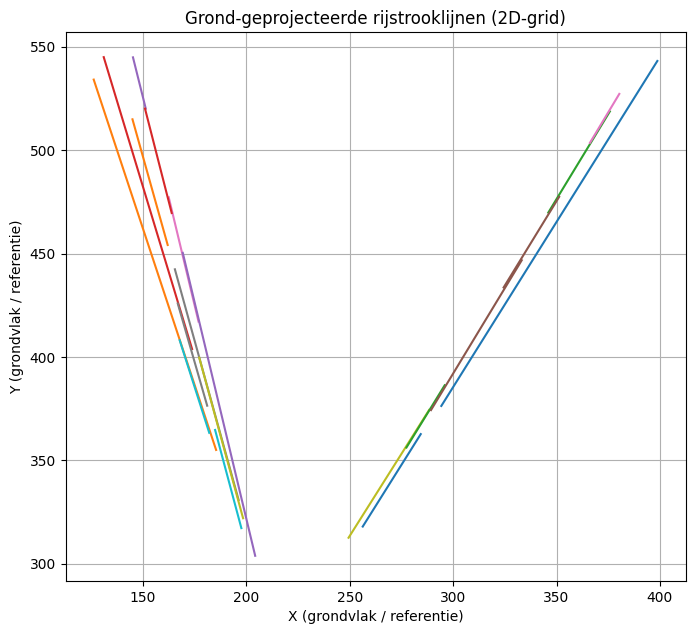

In [33]:
if len(lijnen_grond) == 0:
    print("Geen lijnen om te plotten.")
else:
    plot_grond_lijnen(lijnen_grond, titel="Grond-geprojecteerde rijstrooklijnen (2D-grid)")
